<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExbG04Y2Jycmk0aHpoaWV1cHZwbDc0M2l1em83MGJqYmd0YjB4cnhsdiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/eWdS9hpdeccG4/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Simulation of Finite Difference Method of 2D acoustic wave equation, in heterogneus medium</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Project:</b> AI Surface Seismogram Emulation</p>
    <h5><b>Simulation and data base creation</b></h5>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### Libraries

In [2]:
import sys
print(sys.executable)
## de usar "C:\Users\norma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0"

C:\Users\norma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from IPython.display import display
from matplotlib.animation import FFMpegWriter
import os
from pathlib import Path

In [5]:
from core import *

In [6]:
# Add project root to sys.path
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

### Initial data:

In [7]:
nx = 400
nz = 400
nt = 1500
xmax = 4000
esp = 0.2
c0 = 3000.0
isx = nx // 2
isz = nz // 4
ist = 100
f0 = 100.0
isnap = 10
nop = 5
redFac = 0.8
lenFaul = int(nx * 0.1 / 4)
fsc = 6.0
idisp = 10
anim = 1
norder = 2

# ---------------- Receiver locations ----------------
irx = np.array([nx*0.1, nx*0.25, nx*0.5, nx*0.75, nx*0.9,
                nx*0.1, nx*0.25, nx*0.5, nx*0.75, nx*0.9,
                nx*0.1, nx*0.25, nx*0.5, nx*0.75, nx*0.9], dtype=int)
irz = np.array([10, 10, 10, 10, 10,
                30, 30, 30, 30, 30,
                60, 60, 60, 60, 60], dtype=int)

#### Velocity model

Sample metadata:
{'background_velocity': 3000.0, 'anomaly_center_x': 91.4307946342425, 'anomaly_center_z': 40.099851254721166, 'anomaly_radius_x': 57.580946256198594, 'anomaly_radius_z': 62.881025394655786, 'anomaly_velocity_contrast': -1995.5423423685352}


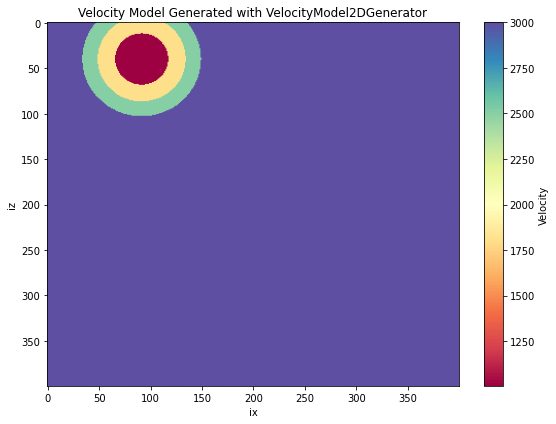

In [8]:
vmg = VelocityModel2DGenerator(
    nx=nx,
    nz=nz,
    background_velocity=c0,
    seed=25,
)

# # Option 1: homogeneous model
# c, sample_metadata = vmg.homogeneous()

# Option 2: one random smooth Gaussian anomaly
c, sample_metadata = vmg.random_gaussian_anomaly(
    x_frac_range=(0.10, 0.90),
    z_frac_range=(0.10, 0.90),
    radius_x_range=(50.0, 85.0),
    radius_z_range=(50.0, 85.0),
    contrast_range=(-2000.0, 200.0),
    clip_min_velocity=300.0,
)

model_type = "gaussian_anomaly"

print("Sample metadata:")
print(sample_metadata)

plt.figure(figsize=(8, 6))
plt.imshow(c, cmap="Spectral", aspect="auto")
plt.colorbar(label="Velocity")
plt.title("Velocity Model Generated with VelocityModel2DGenerator")
plt.xlabel("ix")
plt.ylabel("iz")
plt.tight_layout()
plt.show()

#### Derived numerical parameters

In [9]:
dx = xmax / (nx - 1)
dz = dx
dt = esp * dx / c0

print("Grid increment =", dx)
print("Time Step =", dt, "s")

waveLen = c0 / f0
DivWave = waveLen / dx

print("Wave Length =", waveLen, "m")
print("Number of finite points per Wave Length =", DivWave)

Grid increment = 10.025062656641603
Time Step = 0.0006683375104427735 s
Wave Length = 30.0 m
Number of finite points per Wave Length = 2.9925


#### Source time function

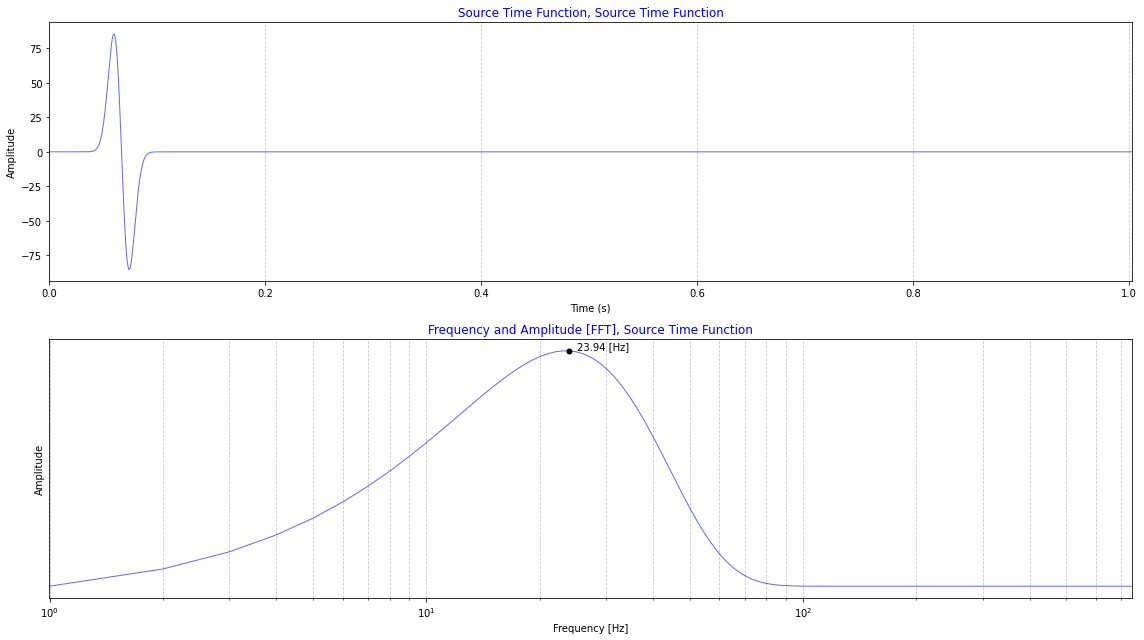

In [10]:
time = np.arange(nt) * dt
src = np.exp(-1.0 / (1.0 / f0**2) * ((time - ist * dt) ** 2))
src = np.gradient(src, dt)

# Optional FFT inspection of source
fft_src_obj = FFt_src(src=src, dt=dt, nt=nt, record="Source Time Function")
frequencies, fft_values, fft_table = fft_src_obj.fft_src()

#### Sample metadata

In [11]:
# For the current fault_zone test, the anomaly-style metadata do not
# strictly apply, so they are stored as NaN except for background velocity.
# Later, when we move to the ML-oriented parametric anomaly models,
# you should fill these with actual values.

sample_metadata = {
    "background_velocity": c0,
    "anomaly_center_x": np.nan,
    "anomaly_center_z": np.nan,
    "anomaly_radius_x": np.nan,
    "anomaly_radius_z": np.nan,
    "anomaly_velocity_contrast": np.nan,
}

#### Simulation

Courant Criterion eps :
0.2


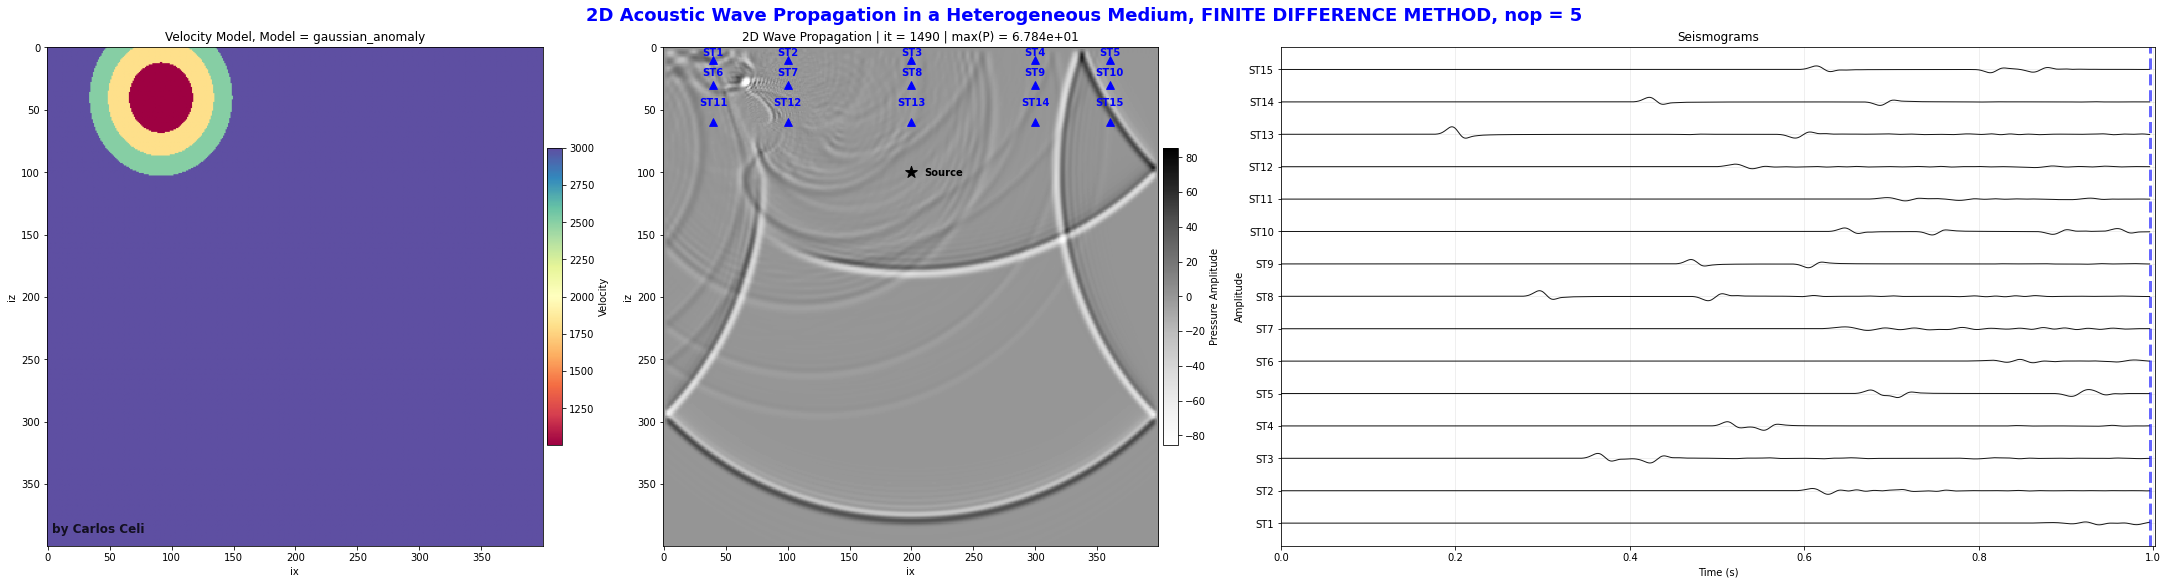

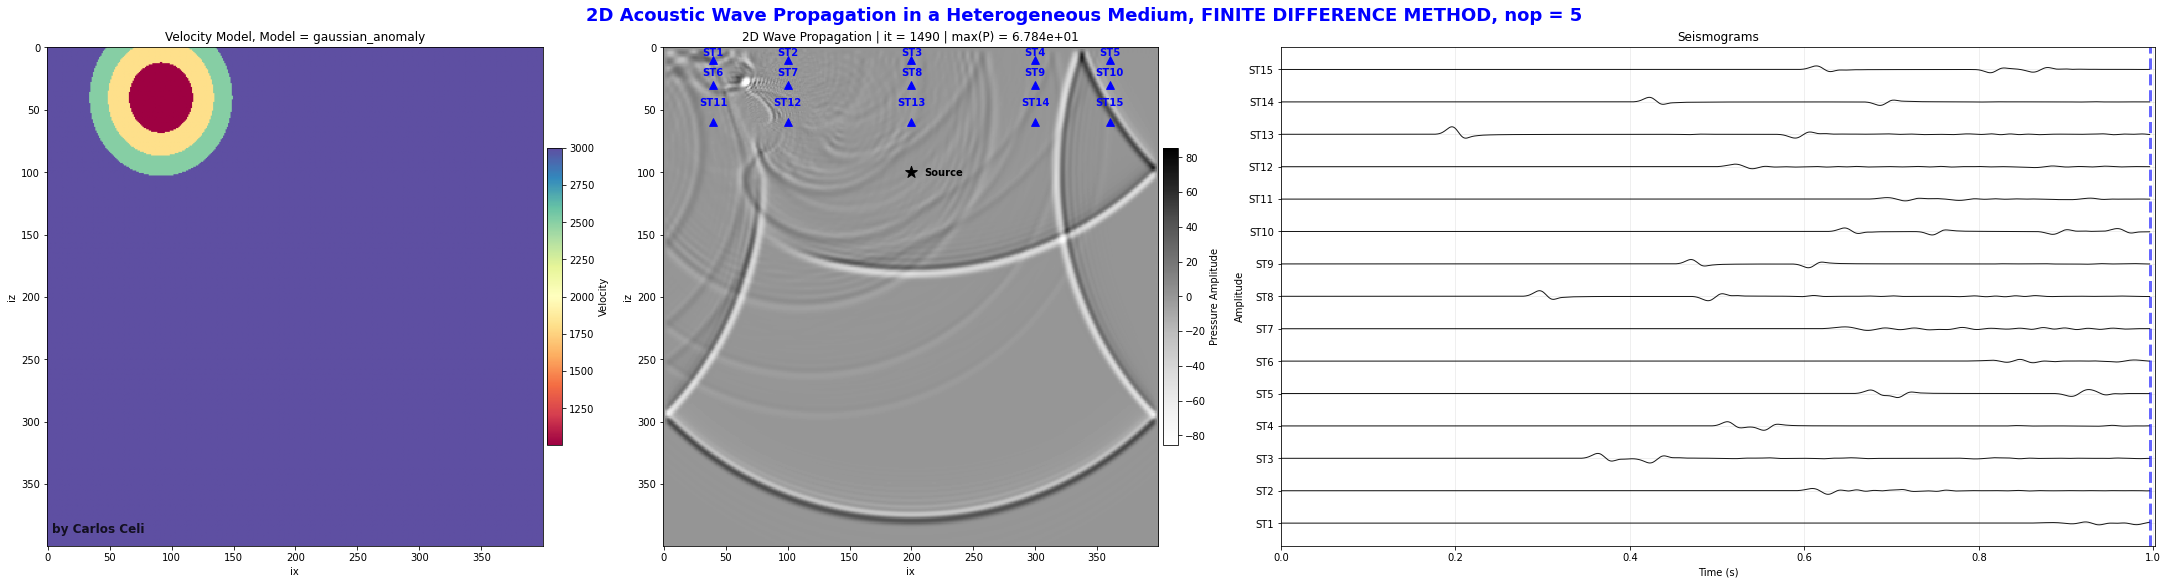

In [12]:
anim2d_FDM = animation2D_FDM(
    nx=nx,nz=nz,dx=dx,dz=dz,dt=dt,nt=nt,
    model_type=model_type,
    c=c,isx=isx,isz=isz,irx=irx,irz=irz,src=src,idisp=idisp,
    nop=nop,fsc=fsc,cmap=plt.cm.Grays,
    show=bool(anim),save=False,             
    video_name=None,fps=10,dpi=120,bitrate=1800,sample_metadata=sample_metadata,
)

results = anim2d_FDM.animate()

#### Quick check of returned results

In [13]:
print("\nReturned keys:")
print(results.keys())

print("\nVelocity model shape:", results["velocity_model"].shape)
print("Surface seismograms shape:", results["surface_seismograms"].shape)
print("Receiver x:", results["receiver_x"])
print("Receiver z:", results["receiver_z"])


Returned keys:
dict_keys(['velocity_model', 'surface_seismograms', 'dx', 'dz', 'dt', 'nx', 'nz', 'nt', 'source_x', 'source_z', 'receiver_x', 'receiver_z', 'model_type', 'sample_metadata'])

Velocity model shape: (400, 400)
Surface seismograms shape: (15, 1500)
Receiver x: [ 40 100 200 300 360  40 100 200 300 360  40 100 200 300 360]
Receiver z: [10 10 10 10 10 30 30 30 30 30 60 60 60 60 60]


#### Write one sample into HDF5

In [14]:
h5_path = project_root / "data" / "raw" / "dataset_surface_seismograms.h5"

writer = HDF5SurfaceSeismogramWriter(h5_path=h5_path)
writer.append_sample(results)

print("\nHDF5 file saved at:")
print(h5_path)

print("\nCurrent number of samples in HDF5:")
print(writer.count_samples())


HDF5 file saved at:
C:\Dropbox\Root\Github Repositories\ai_surface_seismogram_emulation\data\raw\dataset_surface_seismograms.h5

Current number of samples in HDF5:
6


#### Spectrograms

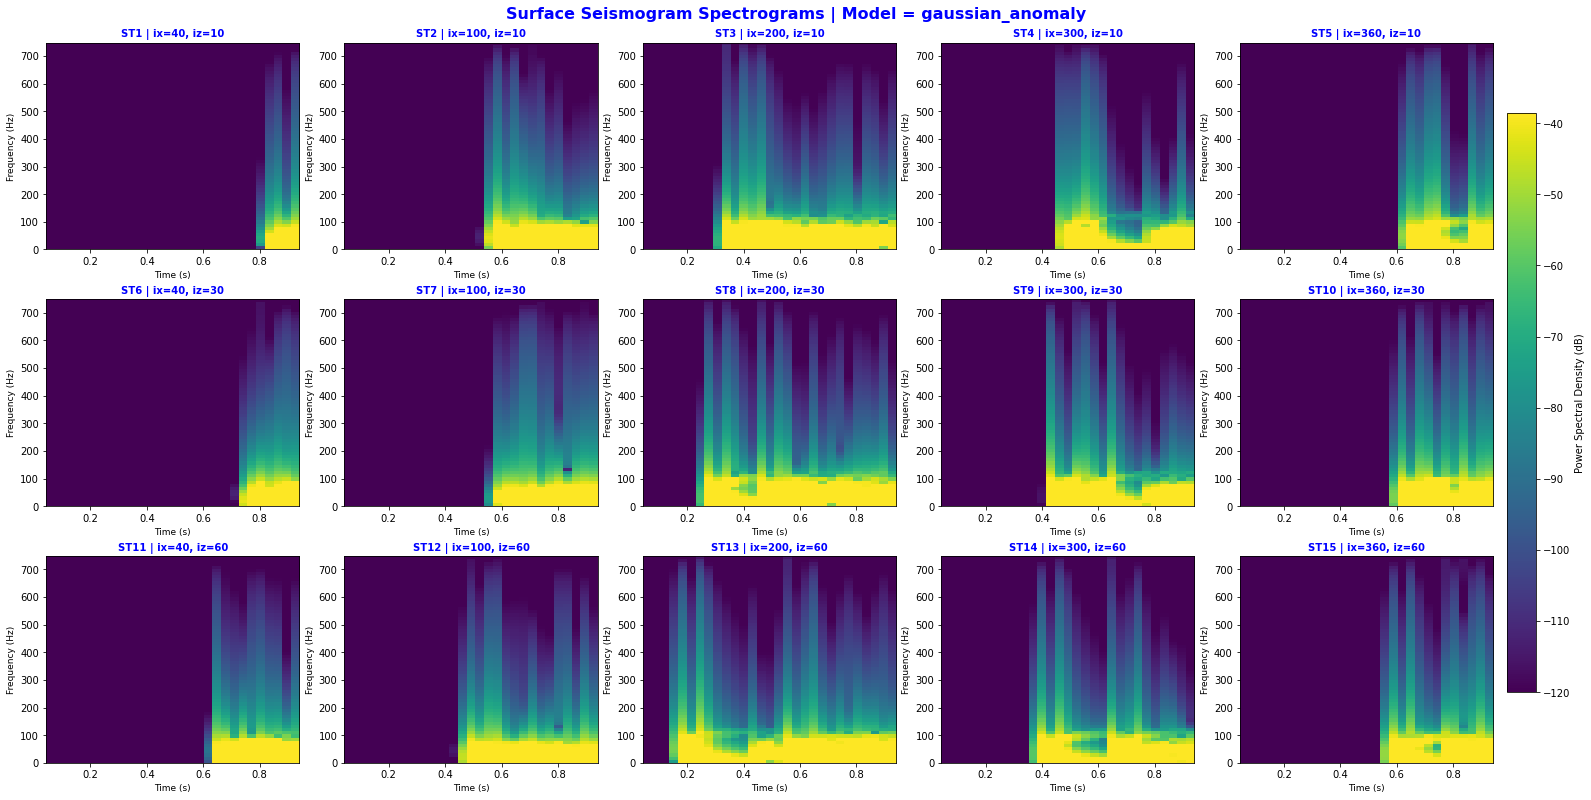

[{'receiver_id': 1,
  'receiver_x': 40,
  'receiver_z': 10,
  'Pxx': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          7.54518777e-01, 2.84696582e-03, 1.61979018e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          1.59777322e+00, 2.23263314e-02, 4.24109858e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          7.58848877e-01, 3.92853346e+00, 6.82437741e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          7.32538912e-13, 4.58660444e-14, 1.10376680e-12],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          4.70361834e-13, 3.36118377e-14, 2.76198018e-13],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          1.91771005e-13, 1.47746653e-14, 1.00673884e-15]]),
  'Pxx_dB': array([[-120.        , -120.        , -120.        , ...,   -1.22329948,
           -25.45617746,    2.09458762],
         [-120.        , -120.        , -120.        , ...,

In [15]:
Spectrograms = SurfaceSeismogramSpectrograms(results,nrows=3,ncols=5,NFFT=128,noverlap=80,cmap="viridis",db_floor=-120.0)

Spectrograms.plot_spectrograms()